# Multimodal Parallel Retrieval Pipeline

## 0. Project Introduction
This notebook shows the ETL and Retrieval pipeline for integrating historical maps ("Water") and archival records ("Ink") of Venice into a unified vector space. The architecture supports four core search modes: Text-to-Image (T2I), Image-to-Image (I2I), Image-to-Text (I2T), and Multilingual Text-to-Text (T2T).

### Pipeline Stages:
1.  **Setup & Configuration:** Initialize paths, parameters, and models.
2.  **Visual Pipeline:** Process maps (patching, PE embedding, TPS georeferencing) and ingest into the Map Collection.
3.  **Text Pipeline:** Process archival data (semantic linearization, dual embedding) and ingest into the Document Collection.
4.  **Multimodal Search Demos:** Execute and visualize cross-modal queries.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

project_root = os.path.abspath(os.path.join(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.patch_utils import extract_patches
from src.feature_extractor import RadioFeatureExtractor
from src.gdal_coordinate_mapper import VeniceGDALMapper
from src.store_data import GeoVectorDB
from src.visualizer import visualize_search_results
from src.text_preprocessor import process_1808_integrated, process_1740_integrated

print("Environment Setup Complete. All modules loaded.")

[Init] Model loaded successfully.
Environment Setup Complete. All modules loaded.


In [2]:
# --- Paths ---
IMAGE_PATH = 'data/raw_maps/venice_map_1.jpg'
GCP_FILE = 'data/raw_maps/venice_map_1.points'

# Text Data (Source Files)
FILE_1808 = "../venice-1808-landregister/venice_1808_landregister_aggregated_data.json"
FILE_1740_TSV = "../venice-1740-landregister/1740_Catastici_2025-09-24.tsv"
FILE_1740_GEO = "../venice-1740-landregister/1740_Catastici_2025-09-24.geojson"

# --- Parameters ---
PATCH_SIZE = (112, 112)
STRIDE = (56, 56)  # 50% overlap for robust feature extraction
MAP_COLLECTION = "venice_historical_map_final"
DOC_COLLECTION = "venice_historical_doc_final"
VECTOR_DIM = 1024  # Perception Encoder Output dimension
NUM_CLUSTERS = 8
# --- Initialize Components ---
# 1. Coordinate Mapper (Thin Plate Spline - TPS)
if os.path.exists(GCP_FILE):
    coord_mapper = VeniceGDALMapper(GCP_FILE)
else:
    print(f"GCP file not found at {GCP_FILE}. Georeferencing will be skipped.")

# 2. Vector Database Client
db = GeoVectorDB(
    host="localhost",
    port=6333,
    map_collection_name=MAP_COLLECTION,
    doc_collection_name=DOC_COLLECTION
)

# 3. Models
# Perception Encoder (PE) for Visual Tasks (1024-d)
# pe_extractor = PEFeatureExtractor(model_name='PE-Core-B16-224')
radio_extractor = RadioFeatureExtractor(default_clusters=NUM_CLUSTERS)
# Multilingual MiniLM for Semantic Search (384-d)
minilm_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("System Components Initialized.")

[GDAL Mapper] Loading GCPs from data/raw_maps/venice_map_1.points...
[GDAL Mapper] TPS Transformer initialized successfully.


D:\anaconda3\envs\urbansearch\Lib\site-packages\osgeo\osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


🚀 加载 RADIO 模型: c-radio_v4-h...


Using cache found in C:\Users\morgan/.cache\torch\hub\NVlabs_RADIO_main
C:\Users\morgan/.cache\torch\hub\NVlabs_RADIO_main\hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ RADIO 初始化成功，显存占用已优化。
System Components Initialized.


In [3]:
VECTOR_DIM = 1280

In [4]:
PATCH_SIZE = (1024, 1024) # 或者 (512, 512)
STRIDE = (512, 512)       # 保持 50% 重叠

In [ ]:
# 建议在 Notebook 开头或上一个 Cell 运行:
# from tqdm.notebook import tqdm
import numpy as np
import os
from PIL import Image

# ==========================================
# 2.1 Load Map & Extract Patches
# ==========================================
if os.path.exists(IMAGE_PATH):
    original_map = Image.open(IMAGE_PATH).convert("RGB")
    print(f"Loaded Map: {IMAGE_PATH} | Size: {original_map.size}")

    # 💡 提示：确保你在之前的 Cell 把 PATCH_SIZE 调大了 (例如 512x512 或 1024x1024)
    # Extract Patches
    patches_data = extract_patches(IMAGE_PATH, patch_size=PATCH_SIZE, stride=STRIDE)
    patch_images = [item['patch'] for item in patches_data]
    patch_coords = [item['coords'] for item in patches_data]

    print(f"Extracted {len(patch_images)} patches.")
else:
    raise FileNotFoundError(f"Map image missing: {IMAGE_PATH}")

# ==========================================
# 2.2 Visual Embedding & Georeferencing (RADIO Version)
# ==========================================

# 1. Generate Embeddings (Visual Vectors)
print("Extracting RADIO dense features and clustering (this may take a moment)...")
all_clusters = []

# 这里使用我们新写的 radio_extractor
# 逐个处理 Patch 以保证显存安全 (因为每个大 Patch 都会产生上千个 dense features)
for img in tqdm(patch_images, desc="RADIO Processing"):
    # 第一步：提取稠密特征
    dense_feats = radio_extractor.extract_dense_features(img)
    # 第二步：将这块区域的特征聚类成 8 个中心
    clusters = radio_extractor.cluster_features(dense_feats, num_clusters=8)

    all_clusters.append(clusters)

# 将结果转为 Numpy 数组，此时 image_features 的形状将是 (N_patches, 8, 1280)
image_features = np.array(all_clusters)
print(f"Feature extraction complete. Shape: {image_features.shape}")


# 2. Georeference Patches (Pixels -> Lat/Lon)
# 💡 这部分逻辑完全保持不变，因为坐标映射与特征维度无关
if 'coord_mapper' in locals():
    registered_patches = coord_mapper.transform_patches(
        patch_coords=patch_coords,
        patch_size=PATCH_SIZE,
        max_workers=8  # Parallel processing
    )
else:
    # Fallback if no GCP file
    registered_patches = [{'index': i, 'pixel_coords': c, 'geo_geometry': {'wgs84': {'center': [0, 0]}}}
                          for i, c in enumerate(patch_coords)]

print(f"Processed {len(registered_patches)} georeferenced patches.")

Loaded Map: data/raw_maps/venice_map_1.jpg | Size: (5500, 2517)
Extracting patches from data/raw_maps/venice_map_1.jpg...


Patching Image: 100%|██████████| 27/27 [00:00<00:00, 566.63it/s]

Successfully extracted 27 patches.
Extracted 27 patches.
Extracting RADIO dense features and clustering (this may take a moment)...


RADIO Processing:   0%|          | 0/27 [00:00<?, ?it/s]

## 2. Visual Pipeline (The "Water" Stream)

### 2.1 Map Patching, Embedding, and Georeferencing
This step transforms the raw map into a vectorized, geographically anchored dataset. We use a 50% overlapping stride to ensure structures on tile edges are fully captured in adjacent tiles. The PE model extracts visual features, and the GDAL TPS engine calculates the geographical coordinates for each patch.

In [3]:
# ==========================================
# 2.1 Load Map & Extract Patches
# ==========================================
if os.path.exists(IMAGE_PATH):
    original_map = Image.open(IMAGE_PATH).convert("RGB")
    print(f"Loaded Map: {IMAGE_PATH} | Size: {original_map.size}")

    # Extract Patches
    patches_data = extract_patches(IMAGE_PATH, patch_size=PATCH_SIZE, stride=STRIDE)
    patch_images = [item['patch'] for item in patches_data]
    patch_coords = [item['coords'] for item in patches_data]

    print(f"Extracted {len(patch_images)} patches.")
else:
    raise FileNotFoundError(f"Map image missing: {IMAGE_PATH}")

# ==========================================
# 2.2 Visual Embedding & Georeferencing
# ==========================================

# 1. Generate Embeddings (Visual Vectors)
print("Extracting visual features (this may take a moment)...")
image_features = pe_extractor.extract_image_features(patch_images, batch_size=64)

# 2. Georeference Patches (Pixels -> Lat/Lon)
# Use the GDAL TPS algorithm for non-linear rectification
if 'coord_mapper' in locals():
    registered_patches = coord_mapper.transform_patches(
        patch_coords=patch_coords,
        patch_size=PATCH_SIZE,
        max_workers=8  # Parallel processing
    )
else:
    # Fallback if no GCP file
    registered_patches = [{'index': i, 'pixel_coords': c, 'geo_geometry': {'wgs84': {'center': [0, 0]}}}
                          for i, c in enumerate(patch_coords)]

print(f"Processed {len(registered_patches)} georeferenced patches.")

Loaded Map: ../data/raw_maps/venice_map_1.jpg | Size: (5500, 2517)
Extracting patches from ../data/raw_maps/venice_map_1.jpg...


Patching Image: 100%|██████████| 4171/4171 [00:00<00:00, 28916.19it/s]


Successfully extracted 4171 patches.
Extracted 4171 patches.
Extracting visual features (this may take a moment)...
Extracting image features using PE-Core-B16-224...


Extracting PE Features: 100%|██████████| 66/66 [02:10<00:00,  1.97s/it]


Registering 4171 patches using 8 threads...


Geo-Rectification: 100%|██████████| 4171/4171 [00:00<00:00, 53210.99it/s]

Successfully registered 4171 patches.
Processed 4171 georeferenced patches.


### 2.3 Map Data Ingestion
The Map Collection is initialized to store single visual vectors (1024-dim).

In [4]:
# ==========================================
# 2.3 Ingest Map Data into Vector DB
# ==========================================

# Initialize Map Collection
db.init_map_collection(vector_dim=VECTOR_DIM, force_recreate=True)

# Upload Data
db.ingest_map_data(
    image_features=image_features,
    registered_data_list=registered_patches,
    source_image_name="1704 Venice",
    year='1704'
)

Collection 'venice_historical_map_final' created successfully.
Starting Ingest: 1704 Venice (Year: 1704) - 4171 slices...


100%|██████████| 4171/4171 [01:32<00:00, 44.88it/s]


Ingestion complete! stored 4171 items.


## 3. Text Pipeline (The "Ink" Stream)

### 3.1 Archival Data Preprocessing and Serialization
This stage processes 1740 and 1808 archival records. The goal is to convert discrete fields into semantically rich, continuous text suitable for vector models. This includes applying semantic chunking and injecting 'Semantic Anchors' for consistent context across text segments. We take the 1740 records for example.

In [5]:
import pandas as pd

df_1740 = pd.read_parquet("data/processed_text/processed_1740.parquet")

### 3.2 Document Data Ingestion
The Document Collection is initialized with dual vector fields: `text_vector` (384-d, MiniLM for semantics) and `pe_vector` (1024-d, PE Text Encoder for visual-text alignment).

In [6]:
# ==========================================
# 3.2 Ingest Documents into Vector DB
# ==========================================

# Initialize Document Collection (Dual Vectors)
db.init_doc_collection(text_dim=384, pe_dim=1024, force_recreate=True)

# Ingest 1740 Data
if not df_1740.empty:
    print("Ingesting 1740 Archives...")
    db.ingest_text_data(df_1740, pe_model=pe_extractor, batch_size=500)

Document collection 'venice_historical_doc_final' created (Text Dim: 384, PE Dim: 1024).
Ingesting 1740 Archives...
PE Model loaded. Generating visual alignment vectors (for Image-to-Text)...
[Text] Starting Ingest: 36880 records...


Uploading Batches: 100%|██████████| 577/577 [13:07<00:00,  1.37s/it]


Text data ingestion complete!


## 4. Multimodal Search Demos

### 4.0 Search Setup
Define helper functions and constants for vector formatting and search limits.

In [9]:
# Helper to format vectors for Qdrant
def to_list(vector):
    if hasattr(vector, 'tolist'):
        vector = vector.tolist()
    if len(vector) == 1 and isinstance(vector[0], list):
        vector = vector[0]
    return vector


K_NEIGHBORS = 15

MAP_COLLECTION = "venice_historical_map_final"
DOC_COLLECTION = "venice_historical_doc_final"

### 4.1 Text-to-Image (T2I)
**Function:** Retrieve visual patches from the map based on a text query.

**Model:** PE Text Encoder (1024-d) -> Map Collection (Visual Vector).


--- Mode 1: Text-to-Image Search ('arched bridge over water') ---


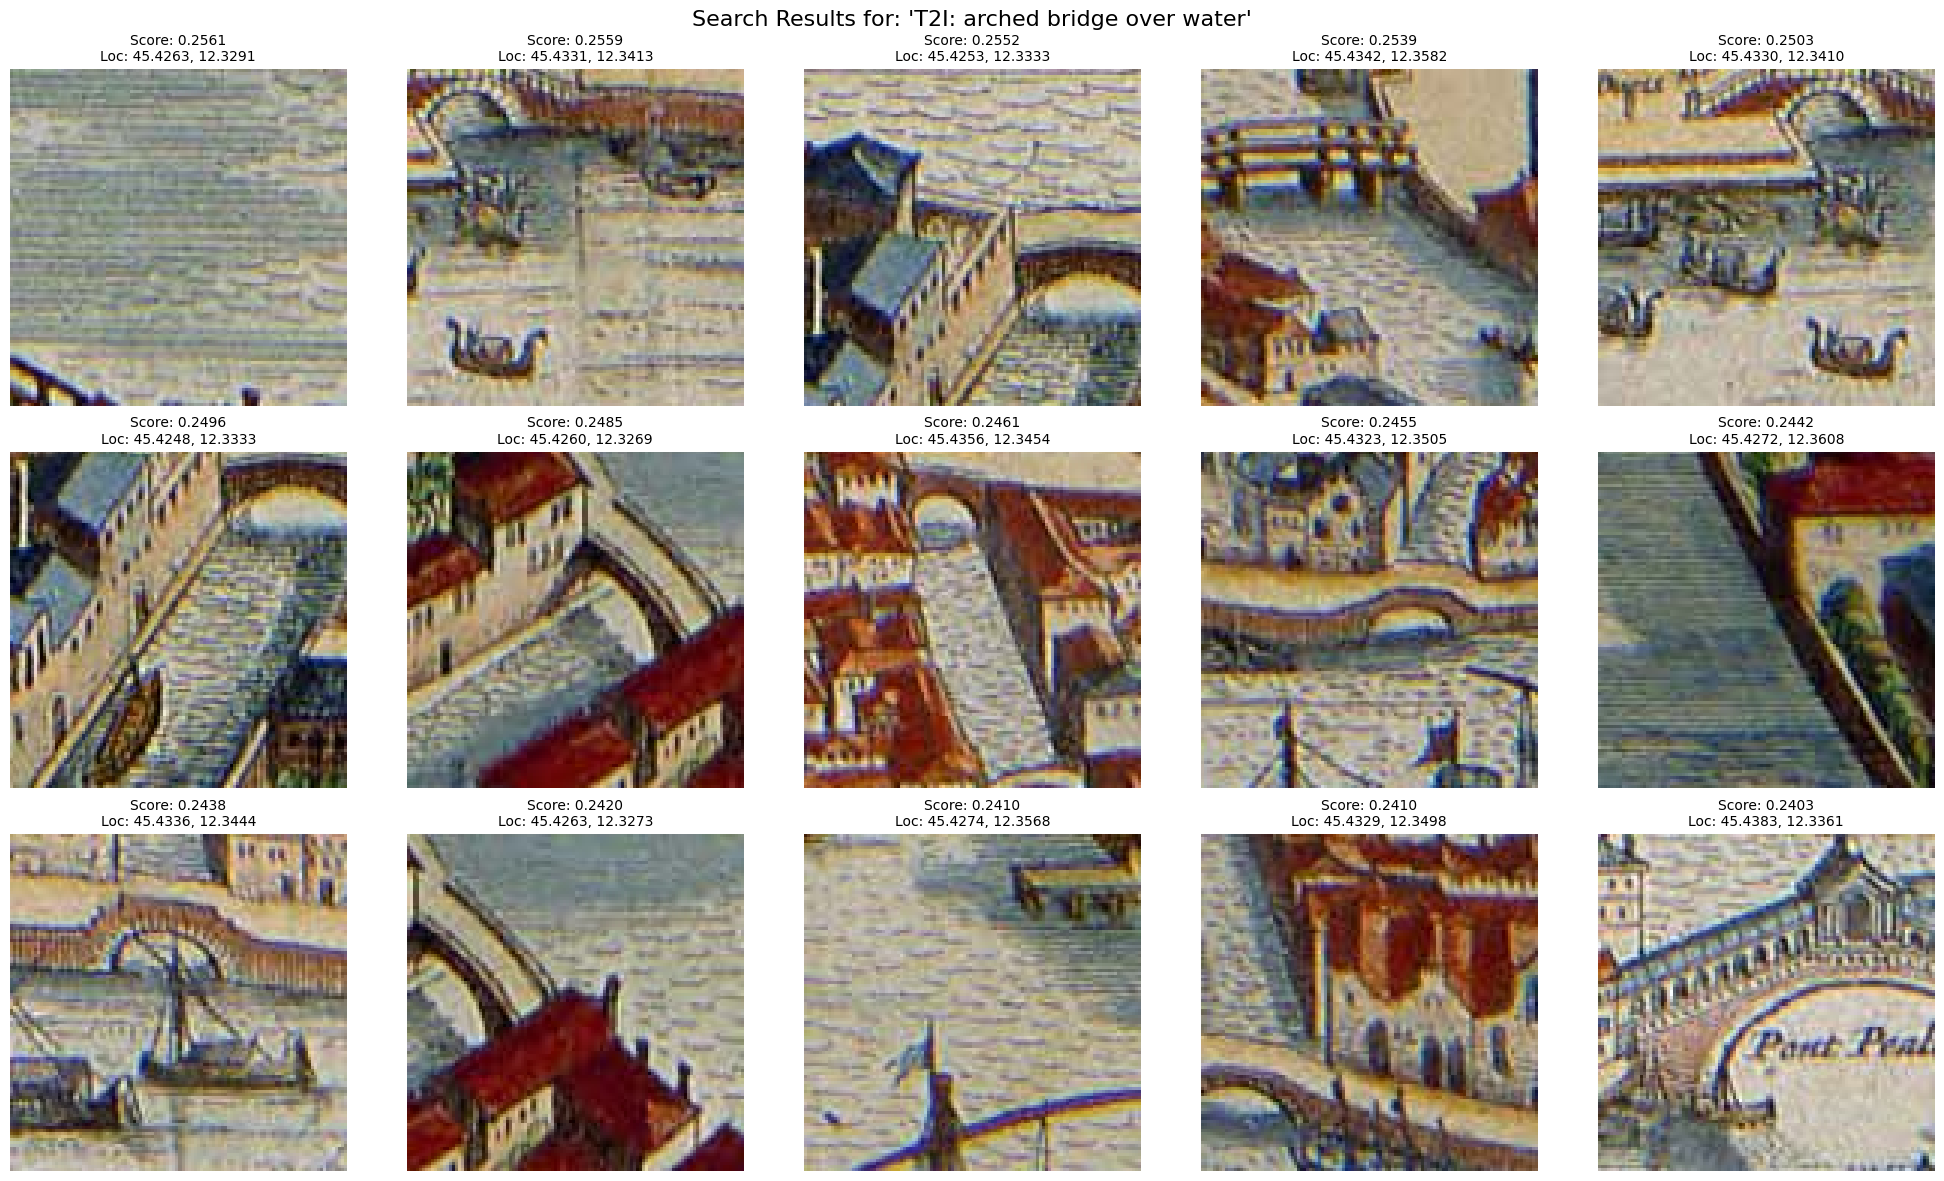

In [10]:
# ==========================================
# Mode 1: Text-to-Image (T2I)
# Query: "Arched bridge over water"
# ==========================================
T2I_QUERY = "arched bridge over water"
print(f"\n--- Mode 1: Text-to-Image Search ('{T2I_QUERY}') ---")

# 1. Encode processed_text using Perception Encoder (Visual Space)
t2i_vector = pe_extractor.extract_text_features(T2I_QUERY)

# 2. Search Map Collection
t2i_results = db.client.query_points(
    collection_name=MAP_COLLECTION,
    query=to_list(t2i_vector),
    limit=K_NEIGHBORS
).points

# 3. Visualize
visualize_search_results(t2i_results, original_map, PATCH_SIZE, f"T2I: {T2I_QUERY}")

### 4.2 Image-to-Image (I2I)
**Function:** Find map regions that are visually similar to a query image.

**Model:** PE Image Encoder (1024-d) -> Map Collection (Visual Vector).


--- Mode 2: Image-to-Image Search ---
Extracting image features using PE-Core-B16-224...


Extracting PE Features: 100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


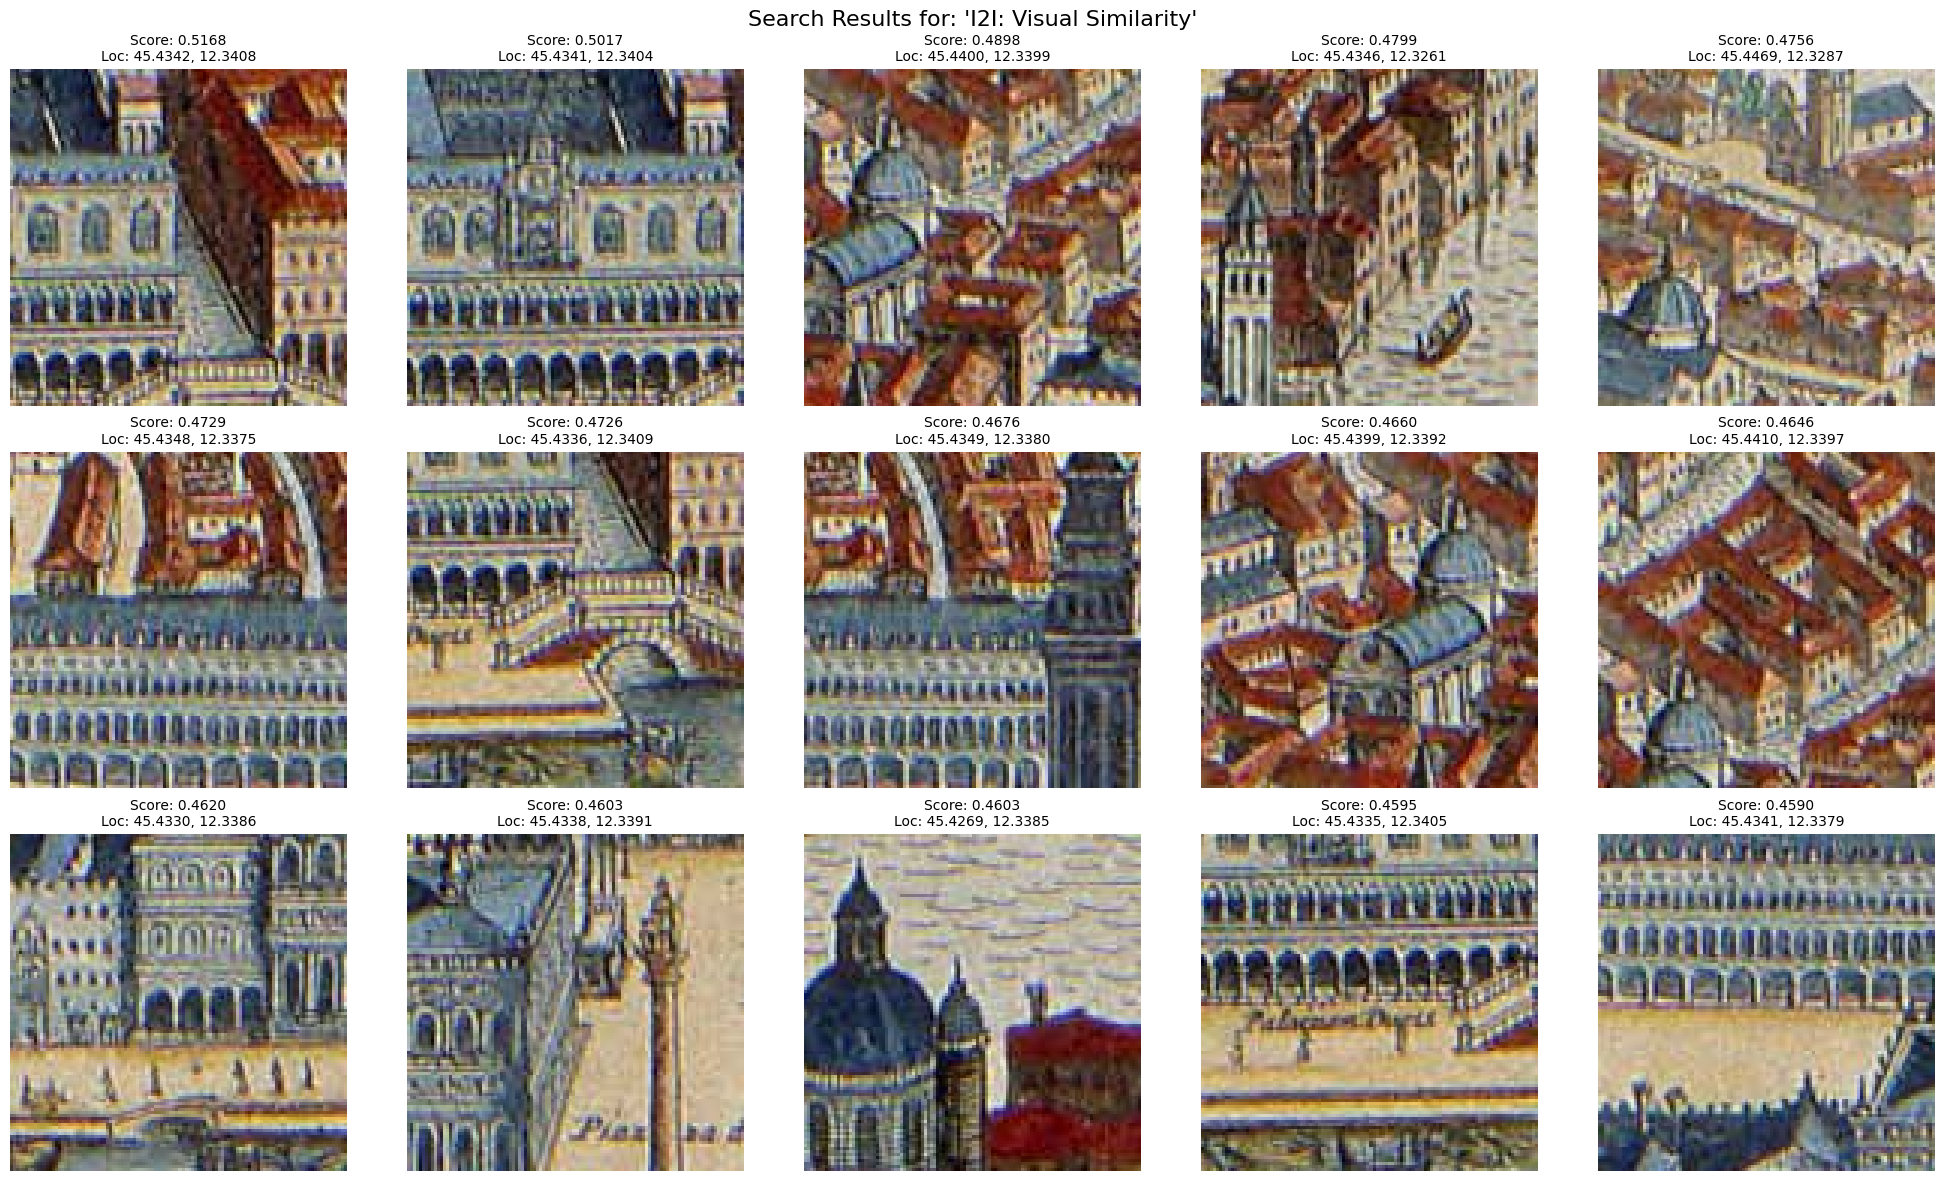

In [11]:
# ==========================================
# Mode 2: Image-to-Image (I2I)
# Scenario: Find similar regions in the map
# ==========================================
print("\n--- Mode 2: Image-to-Image Search ---")

# 1. Use a pic of san marco as a query image
query_image = Image.open("san marco.jpg")

# 2. Extract Visual Feature (PE Model)
i2i_vector = pe_extractor.extract_image_features([query_image])[0]

# 3. Search Map Collection
i2i_results = db.client.query_points(
    collection_name=MAP_COLLECTION,
    query=to_list(i2i_vector),
    limit=K_NEIGHBORS
).points

# 4. Visualize
visualize_search_results(i2i_results, original_map, PATCH_SIZE, "I2I: Visual Similarity")

### 4.3 Mode 3: Image-to-Text (I2T)
**Function:** Use a image to retrieve historical archives that describe similar visual features.

**Model:** PE Image Encoder (1024-d) -> Document Collection (`pe_vector` - Visual Alignment Space).

In [12]:
# ==========================================
# Mode 3: Image-to-Text (I2T)
# Scenario: What historical records describe this visual place?
# ==========================================
print("\n--- Mode 3: Image-to-Text Search ---")

# 1. Reuse the vector from I2I (Visual Space)
i2t_vector = i2i_vector

# 2. Search Document Collection using 'pe_vector' field
i2t_results = db.client.query_points(
    collection_name=DOC_COLLECTION,
    query=to_list(i2t_vector),
    using="pe_vector",
    limit=5
).points

# 3. Display Results
print(f"Documents visually similar to the query image:")
for hit in i2t_results:
    content = hit.payload.get('content', '')[:150].replace('\n', ' ')
    year = hit.payload.get('year', 'Unknown')
    print(f"  [Score: {hit.score:.4f}] [{year}] {content}...")


--- Mode 3: Image-to-Text Search ---
Documents visually similar to the query image:
  [Score: 0.2286] [1740] This is a CASA owned by Palazzo del Serenissimo Doge e fratelli Pisani located in San Marco (San Vidal). Details: District: San Marco. Parish: San Vid...
  [Score: 0.2285] [1740] This is a CASA owned by Monastero di San Giorgio Maggiore located in San Marco (San Zulian). Details: District: San Marco. Parish: San Zulian. Place: ...
  [Score: 0.2285] [1740] This is a CASA owned by Monastero di San Giorgio Maggiore located in San Marco (San Zulian). Details: District: San Marco. Parish: San Zulian. Place: ...
  [Score: 0.2284] [1740] This is a Campo Santo owned by Reverendi Padri di S. Steffano located in San Marco (Sant'Angelo). Details: District: San Marco. Parish: Sant'Angelo. P...
  [Score: 0.2283] [1740] This is a MIXED owned by Reverendi Padri di San Giorgio Maggiore located in San Marco (San Zulian). Details: District: San Marco. Parish: San Zulian. ...


### 4.4 Mode 4: Text-to-Text (T2T) - Multilingual Semantic Search
**Function:** Search for similar text records using multilingual input (English, Italian, etc.).

**Model:** MiniLM (384-d) -> Document Collection (`text_vector` - Semantic Space).

In [13]:
# ==========================================
# Mode 4: Text-to-Text (T2T) - Multilingual
# Scenario: Search for abstract concepts in any language
# ==========================================
T2T_QUERY = "church"  # English Query

print(f"\n--- Mode 4: Text-to-Text Search ('{T2T_QUERY}') ---")

# 1. Encode processed_text using MiniLM (Semantic Space)
t2t_vector = minilm_model.encode(T2T_QUERY)

# 2. Search Document Collection using 'text_vector' field
t2t_results = db.client.query_points(
    collection_name=DOC_COLLECTION,
    query=to_list(t2t_vector),
    using="text_vector",  # Explicitly use the semantic vector
    limit=5
).points

# 3. Display Results
for hit in t2t_results:
    content = hit.payload.get('content', '')[:150].replace('\n', ' ')
    year = hit.payload.get('year', 'Unknown')
    print(f"  [Score: {hit.score:.4f}] [{year}] {content}...")


--- Mode 4: Text-to-Text Search ('church') ---
  [Score: 0.5059] [1740] This is a OTHER owned by Chiesa dell'Umiltà con il Monastero delle Monache located in Dorsoduro (San Gregorio). Details: District: Dorsoduro. Parish: ...
  [Score: 0.5045] [1740] This is a OTHER owned by Congregazione della Commissaria Centarini located in Cannaregio (San Geremia). Details: District: Cannaregio. Parish: San Ger...
  [Score: 0.4846] [1740] This is a OTHER owned by Monastero di San Gerolamo located in Cannaregio (San Marcuola). Details: District: Cannaregio. Parish: San Marcuola. Place: I...
  [Score: 0.4788] [1740] This is a OTHER owned by Monastero della Salute con il Monastero delli Reverendi Chierici Regolari Somaschi located in Dorsoduro (San Gregorio). Detai...
  [Score: 0.4786] [1740] This is a BOTTEGA owned by Monastero delle vergini located in San Marco (San Bortolomio). Details: District: San Marco. Parish: San Bortolomio. Place:...
